## Lab 2: final challenges

__Вам предлагается решить задачу классификации сигналов или задачу классификации изображений. Или обе ;)__

__Выполнение этих заданий не является обязательным, но позитивно повлияет на вашу итоговую оценку. Успехов!__


### Part 4. HAR classification with raw data (2+ points)
__Disclaimer__: Это опциональная часть задания. Здесь придется экспериментировать, подбирать оптимальную структуру сети для решения задачи и активно искать подскзаки в сети.


Данное задание составлено на основе данного [поста](https://burakhimmetoglu.com/2017/08/22/time-series-classification-with-tensorflow/). С помощью вручную сгенерированных фичей и классических подходов задача распознования движений была решена с точностью 96%.

Также будет полезным изучить [вот этот](https://github.com/healthDataScience/deep-learning-HAR), а так же [вот этот репозиторий](https://github.com/guillaume-chevalier/LSTM-Human-Activity-Recognition), где к данной задаче рассматривается несколько подходов.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import pylab
import warnings as w
import os

%matplotlib inline

In [5]:
import matplotlib
matplotlib.rcParams.update({'font.size':14})

Вернемся к задаче классификации движений на основе [данных](https://archive.ics.uci.edu/ml/datasets/Human+Activity+Recognition+Using+Smartphones) из репозитория UCI ([прямая ссылка на скачивание](https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip)).

В этот раз будем работать с исходными, а не предобработанными данными. Данные представляют собой сигналы с гироскопа и акселерометра, закрепленного на теле человека. Каждому семплу соотвествует 9 связанных временных рядов.

В начале приведена визуализация данных на основе PCA над вручную сгенерированными признаками. Для отрисовки графиков (цвет и легенда) нам также понадобятся метки классов.

In [6]:
import urllib.request
import zipfile
import os

# Скачиваем датасет
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "UCI_HAR_Dataset.zip"

if not os.path.exists("UCI HAR Dataset"):
    print("Скачиваем датасет...")
    urllib.request.urlretrieve(url, zip_path)

    print("Распаковываем...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(".")

    # Удаляем архив
    os.remove(zip_path)
    print("Готово!")
else:
    print("Датасет уже скачан")


Скачиваем датасет...
Распаковываем...
Готово!


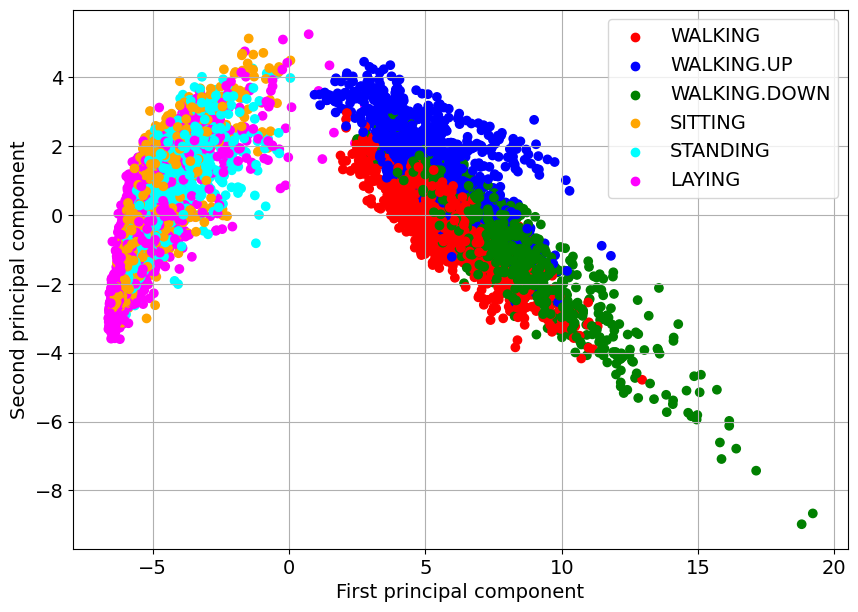

In [7]:
X_train_with_engineered_features = np.genfromtxt(os.path.join("UCI HAR Dataset", "train", "X_train.txt"))
y_train = np.genfromtxt(os.path.join("UCI HAR Dataset", "train", "y_train.txt"))

y_train_list = list(y_train)
X_unique = np.array([X_train_with_engineered_features[y_train_list.index(l)]
                             for l in sorted(list(set(y_train)))])

legend_labels = ["WALKING", "WALKING.UP", "WALKING.DOWN", "SITTING", "STANDING", "LAYING"]
colors_list = ['red', 'blue', 'green', 'orange', 'cyan', 'magenta']
mapped_colors = [colors_list[int(i)-1] for i in y_train]

from sklearn.decomposition import PCA
pca = PCA()

X_train_pca = pca.fit_transform(X_train_with_engineered_features)

plt.figure(figsize=(10,7))
pylab.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
             c=mapped_colors)
plt.grid()
for idx, x in enumerate(pca.transform(X_unique)):
    plt.scatter(x[0],
                x[1],
                c=colors_list[idx],
                label=legend_labels[idx])
plt.xlabel('First principal component')
plt.ylabel('Second principal component')
plt.legend()

#### Предобработка данных
Предобработка сделана за нас автором [данного репозитория](https://github.com/guillaume-chevalier/LSTM-Human-Activity-Recognition). Будьте осторожны с путями.

In [8]:
# Useful Constants

# Those are separate normalised input features for the neural network
INPUT_SIGNAL_TYPES = [
    "body_acc_x_",
    "body_acc_y_",
    "body_acc_z_",
    "body_gyro_x_",
    "body_gyro_y_",
    "body_gyro_z_",
    "total_acc_x_",
    "total_acc_y_",
    "total_acc_z_"
]

# Output classes to learn how to classify
LABELS = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

DATA_PATH = "./"

DATASET_PATH = DATA_PATH + "UCI HAR Dataset/"
print("\n" + "Dataset is now located at: " + DATASET_PATH)

TRAIN = "train/"
TEST = "test/"


# Load "X" (the neural network's training and testing inputs)

def load_X(X_signals_paths):
    X_signals = []

    for signal_type_path in X_signals_paths:
        file = open(signal_type_path, 'r')
        # Read dataset from disk, dealing with text files' syntax
        X_signals.append(
            [np.array(serie, dtype=np.float32) for serie in [
                row.replace('  ', ' ').strip().split(' ') for row in file
            ]]
        )
        file.close()

    return np.transpose(np.array(X_signals), (1, 2, 0))

X_train_signals_paths = [
    os.path.join(*[DATASET_PATH, TRAIN, "Inertial Signals/", signal+"train.txt"]) for signal in INPUT_SIGNAL_TYPES
]
X_test_signals_paths = [
    os.path.join(*[DATASET_PATH, TEST, "Inertial Signals/", signal+"test.txt"]) for signal in INPUT_SIGNAL_TYPES
]

X_train = load_X(X_train_signals_paths)
X_test = load_X(X_test_signals_paths)


# Load "y" (the neural network's training and testing outputs)

def load_y(y_path):
    file = open(y_path, 'r')
    # Read dataset from disk, dealing with text file's syntax
    y_ = np.array(
        [elem for elem in [
            row.replace('  ', ' ').strip().split(' ') for row in file
        ]],
        dtype=np.int32
    )
    file.close()

    # Substract 1 to each output class for friendly 0-based indexing
    return y_ - 1

y_train_path = os.path.join(DATASET_PATH, TRAIN, "y_train.txt")
y_test_path = os.path.join(DATASET_PATH, TEST, "y_test.txt")

y_train = load_y(y_train_path)
y_test = load_y(y_test_path)


Dataset is now located at: ./UCI HAR Dataset/


In [9]:
# Input Data

training_data_count = len(X_train)  # 7352 training series (with 50% overlap between each serie)
test_data_count = len(X_test)  # 2947 testing series
n_steps = len(X_train[0])  # 128 timesteps per series
n_input = len(X_train[0][0])  # 9 input parameters per timestep


# LSTM Neural Network's internal structure

n_hidden = 32 # Hidden layer num of features
n_classes = 6 # Total classes (should go up, or should go down)


# Some debugging info

print("Some useful info to get an insight on dataset's shape and normalisation:")
print("(X shape, y shape, every X's mean, every X's standard deviation)")
print(X_test.shape, y_test.shape, np.mean(X_test), np.std(X_test))
print("The dataset is therefore properly normalised, as expected, but not yet one-hot encoded.")

Some useful info to get an insight on dataset's shape and normalisation:
(X shape, y shape, every X's mean, every X's standard deviation)
(2947, 128, 9) (2947, 1) 0.09913992 0.39567086
The dataset is therefore properly normalised, as expected, but not yet one-hot encoded.


#### Построение сети и эксперименты. (100% +)

__Ваша задача - построить сеть, которая решит задачу классификации с точностью (`accuracy`) не менее 86%.__
Разбалловка следующая:
* $=$86% - 2 points
* $>=$89% - 2.5 points
* $>=$91% - 3 points


__Warning!__ В сети существует несколько решений данной задачи с использованием различных фреймворков. При проверке это будет учитываться, так что свое решение нужно будет объяснить. Пожалуйста, не копируйте бездумно код, такие задания будут оценены 0 баллов. Если задача не решается - можете обратиться к заданию по классификации изображений.

После выполнения задания заполните небольшой отчет об экспериментах вида "Я пробовал(а) ... подходы и получил(а) ... результаты. Наконец, после N+1 чашки кофе/бессонной ночи у меня получилось, и весь секрет был в ..."

In [10]:
# дополнительный код для адаптированного вывода tqdm без виджетов
import sys
from io import StringIO
from collections import deque

class TTYStringIO(StringIO):
    def __init__(self, n=3):
        super().__init__()
        self.n = n
        self._history = deque(maxlen=n)

    def write(self, s):
        # \x1b[A - это стрелка вверх
        self._history.append(s)
        return super().write(s)

    def get_last_line(self, num=-1):
        """
        Возвращает запись по отрицательному индексу:
        - num=-1  последняя (самая свежая)
        - num=-2  предпоследняя
        - ...
        Если индекс выходит за пределы (например, num=-100 при 3 записях) - вернёт "".
        """
        try:
            return self._history[num]
        except IndexError:
            return "IndexError"

    def isatty(self):
        return False  # говорим tqdm: "я не терминал!" ;))

buf = TTYStringIO()

In [11]:
# Your experiments here

from tqdm import tqdm

#LSTM

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используем устройство: {device}")

# X_train имеет форму (n_samples, n_timesteps, n_features) = (7352, 128, 9)
# y_train имеет форму (n_samples, 1)

X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train.flatten())
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test.flatten())

batch_size = 64

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.5):
        super(LSTMClassifier, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # LSTM слои
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True  # Двунаправленный LSTM ?
        )

        # Полносвязные слои
        self.fc = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),  # *2 из-за bidirectional
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # x: (batch_size, seq_len, input_size)

        # LSTM forward
        lstm_out, (h_n, c_n) = self.lstm(x)
        # lstm_out: (batch_size, seq_len, hidden_size * 2)

        # выход с последнего шага по времени
        out = lstm_out[:, -1, :]

        # классификация
        out = self.fc(out)
        return out

# ГИПЕРПАРАМЕТРЫ ТУТ
input_size = 9       # 9 сенсоров
hidden_size = 128
num_layers = 2       # Количество LSTM слоёв
num_classes = 6      # 6 меток классов (виды активности персонажей)
dropout = 0.5
learning_rate = 0.001
num_epochs = 50

model = LSTMClassifier(input_size, hidden_size, num_layers, num_classes, dropout).to(device)
print(model)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
#scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, verbose=True)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

def evaluate(model, data_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs.data, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
    return correct / total



Используем устройство: cuda
LSTMClassifier(
  (lstm): LSTM(9, 128, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (fc): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=64, out_features=6, bias=True)
  )
)


In [12]:
# погнали обучение
train_losses = []
train_accs = []
test_accs = []
best_acc = 0

print("\nНачинаем обучение...")
print("-" * 60)

epoch_pbar = tqdm(range(num_epochs), desc='Epochs', file=buf, ascii=True, postfix={})

#for epoch in range(num_epochs):
for epoch in epoch_pbar:

    sys.stdout.write(buf.get_last_line()+'\n')

    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    batch_pbar = tqdm(train_loader,total=len(train_loader), desc=f'Epoch {epoch+1}',
                      file=buf, ascii=False, leave=False, postfix={})

    #for X_batch, y_batch in train_loader:
    for X_batch, y_batch in batch_pbar:

        s = buf.get_last_line(-1)
        if s == "\x1b[A":
             s = buf.get_last_line(-2)
        #sys.stdout.write("\n====\n")
        if len(s) > 0:
            #sys.stdout.write(f'{repr(s)}')
            sys.stdout.write(f'{s}')
        else:
            sys.stdout.write(f's is empty')
        #sys.stdout.write("\n====\n")

        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # прямой
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        # обратный
        optimizer.zero_grad()
        loss.backward()

        # gradient clipping для стабильности ? чтобы это ни значило
        # потом почитаю ;))
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

        #batch_pbar.set_postfix({'running_loss': f'{running_los/):.4f}'})

    # метрики за эпоху
    epoch_loss = running_loss / len(train_loader)
    train_acc = correct / total
    test_acc = evaluate(model, test_loader)

    train_losses.append(epoch_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    # тут будет (возможно) обновлен learning rate
    scheduler.step(test_acc)

    # сохраняем лучшую модель
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), 'best_model.pth')

    #if (epoch + 1) % 5 == 0:
    #    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {epoch_loss:.4f} | "
    #          f"Train Acc: {train_acc*100:.2f}% | Test Acc: {test_acc*100:.2f}%")

    epoch_pbar.set_postfix( {'loss': f'{epoch_loss:.4f}',
                             'Train Acc': f'{train_acc*100:.2f}',
                             'Test Acc': f'{test_acc*100:.2f}',
                            }
                          )

print("-" * 60)
print(f"Лучшая точность на тесте: {best_acc*100:.2f}%")




Начинаем обучение...
------------------------------------------------------------
Epoch 50:  97%|█████████▋| 112/115 [00:01<00:00, 65.08it/s]------------------------------------------------------------
Лучшая точность на тесте: 91.92%


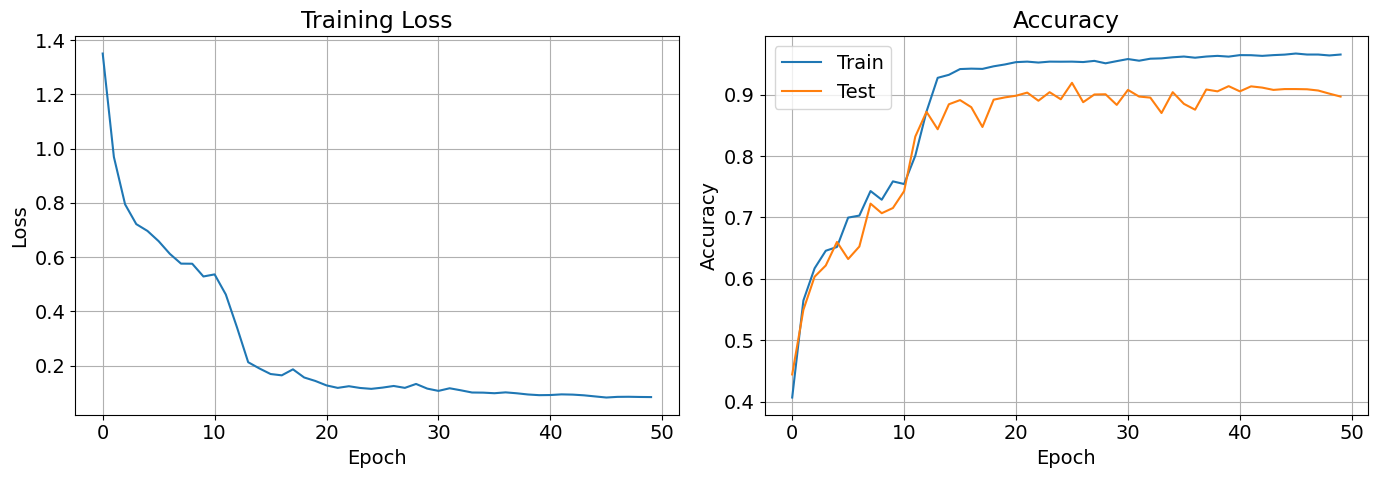


Финальная точность на тестовой выборке: 91.92%


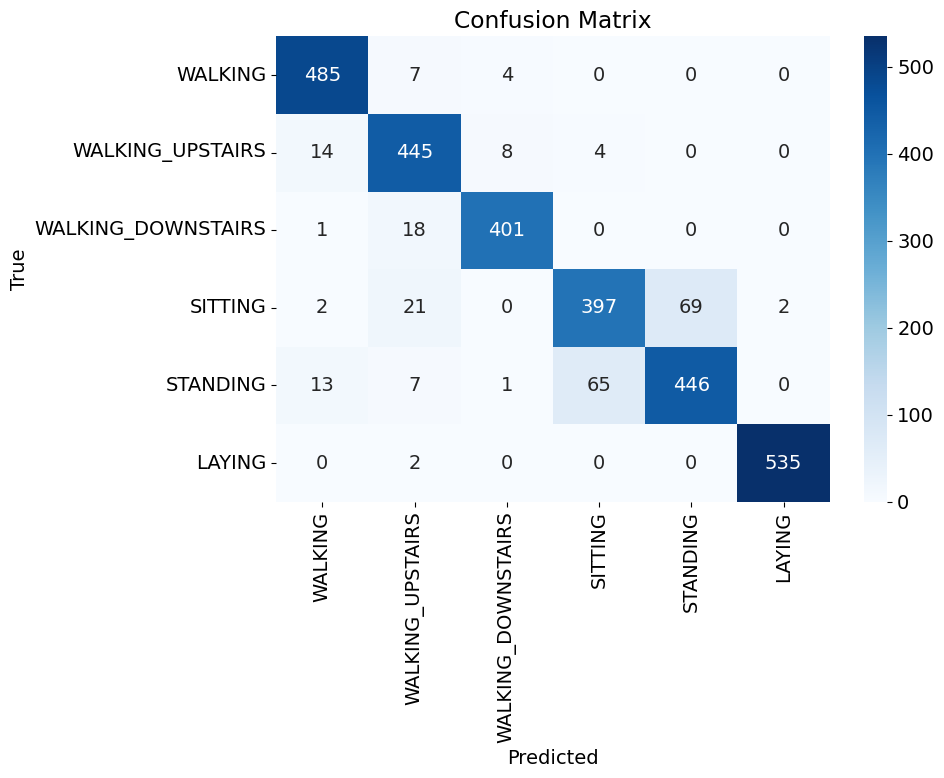


Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.94      0.98      0.96       496
  WALKING_UPSTAIRS       0.89      0.94      0.92       471
WALKING_DOWNSTAIRS       0.97      0.95      0.96       420
           SITTING       0.85      0.81      0.83       491
          STANDING       0.87      0.84      0.85       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.92      2947
         macro avg       0.92      0.92      0.92      2947
      weighted avg       0.92      0.92      0.92      2947



In [13]:
# графики обучения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True)

axes[1].plot(train_accs, label='Train')
axes[1].plot(test_accs, label='Test')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# загружаем лучшую модель по эпохам
model.load_state_dict(torch.load('best_model.pth'))
final_acc = evaluate(model, test_loader)
print(f"\nФинальная точность на тестовой выборке: {final_acc*100:.2f}%")

# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABELS, yticklabels=LABELS)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=LABELS))

## <font color=brown>Как ни странно, но сходу получился вполне приличный результат ;))</font>

### Part 5. Dogs classification (2+ points)
__Disclaimer__: Это опциональная часть задания. Здесь придется экспериментировать, подбирать оптимальную структуру сети для решения задачи и активно искать подскзаки в сети.

Предлагаем вам решить задачу классификации пород собак. Вы можете обучить сеть с нуля или же воспользоваться методом fine-tuning'а. Полезная ссылка на [предобученные модели](https://pytorch.org/docs/stable/torchvision/models.html).

Данные можно скачать [отсюда](https://www.dropbox.com/s/vgqpz2f1lolxmlv/data.zip?dl=0). Датасет представлен 50 классами пород собак, которые можно найти в папке train в соответствующих директориях. При сдаче данной части задания вместе с ноутбуком необходимо отправить .csv-файл с предсказаниями классов тестовой выборки в формате: <имя изображения>,<метка класса> по одному объекту на строку. Ниже приведите код ваших экспериментов и короткий вывод по их результатам.

Будут оцениваться качество классификации (accuracy) на тестовой выборке (2 балла) и проведенные эксперименты (1 балл).
Разбалловка следующая:
* $>=$93% - 2 points
* $>=$84% - 1.5 points
* $>=$70% - 0.75 points

In [ ]:
# Your experiments here